<a href="https://colab.research.google.com/github/samsarkar184/ML-Projects/blob/main/SSL_first_miniproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#importing libraries
import torch
import torchvision
import matplotlib.pyplot as plt
print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
#check versions
print("Pytorch version :",torch.__version__)
print("Torchvision version :",torchvision.__version__)

Pytorch version : 2.11.0+cu128
Torchvision version : 0.26.0+cu128


In [3]:
#gpu or cpu
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using :",device)

Using : cuda


In [4]:
from torchvision import datasets,transforms
transform=transforms.ToTensor()

In [5]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor()
])

In [6]:
#load CIFAR-10 train dataset
train_dataset=datasets.CIFAR10(root="./data",
                               train=True,
                               download=True,
                               transform=train_transform)

100%|██████████| 170M/170M [00:08<00:00, 19.9MB/s]


In [7]:
#show the shape and label of the image sample
image,label=train_dataset[0]
print("Image shape :",image.shape)
print("Image label :",label)



Image shape : torch.Size([3, 32, 32])
Image label : 6


In [8]:
#load CIFAR-10 test dataset
test_dataset=datasets.CIFAR10(root="./data",
                              train=False,
                              download=True,
                              transform=transform)


In [9]:
#show number of images in train and test dataset
print("Training images:",len(train_dataset))
print("Test images:",len(test_dataset))

Training images: 50000
Test images: 10000


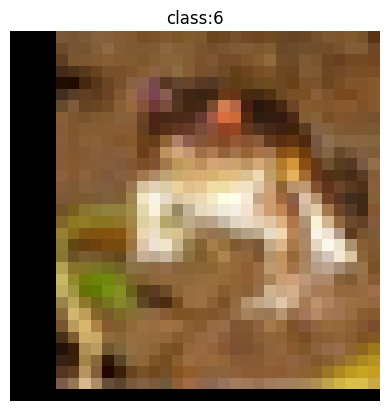

In [10]:
#show an image
plt.imshow(image.permute(1,2,0))
plt.title(f"class:{label}")
plt.axis("off")
plt.show()

In [11]:
import torch.nn as nn
import torch.nn.functional as F
class SimpleCNN(nn.Module):
  def __init__(self) -> None:
      super(SimpleCNN,self).__init__()
      self.conv1=nn.Conv2d(3,16,kernel_size=3,padding=1)
      self.conv2=nn.Conv2d(16,32,kernel_size=3,padding=1)

      self.fc1=nn.Linear(32*8*8,128)
      self.fc2=nn.Linear(128,10)

  def forward(self,x):
    x=F.relu(self.conv1(x))
    x=F.max_pool2d(x,2)

    x=F.relu(self.conv2(x))
    x=F.max_pool2d(x,2)

    x=torch.flatten(x,1)
    embedding=F.relu(self.fc1(x))

    output=self.fc2(embedding)

    return output,embedding
model=SimpleCNN()
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=2048, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [12]:
x=torch.randn(1,3,32,32)
output,embedding=model(x)
print("Image shape:",output.shape)
print("Output embedding:",embedding.shape)
print(embedding)

Image shape: torch.Size([1, 10])
Output embedding: torch.Size([1, 128])
tensor([[0.0000, 0.0000, 0.0610, 0.0000, 0.0000, 0.0000, 0.0701, 0.3811, 0.4670,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.6314, 0.1614, 0.0000, 0.0000, 0.0000, 0.0000, 0.3054, 0.3292, 0.4178,
         0.0000, 0.0000, 0.0000, 0.0000, 0.1168, 0.6429, 0.0000, 0.0000, 0.4238,
         0.0230, 0.2121, 0.0000, 0.0000, 0.5326, 0.1610, 0.0000, 0.0000, 0.4502,
         0.0376, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.2318, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0673, 0.0000, 0.4065, 0.0000, 0.2735, 0.0608, 0.0000,
         0.4211, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.2063, 0.0000, 0.0000,
         0.0000, 0.0856, 0.0000, 0.0000, 0.6624, 0.1875, 0.3245, 0.5502, 0.5802,
         0.0000, 0.0000, 0.1287, 0.0613, 0.0000, 0.0000, 0.0000, 0.2569, 0.0000,
         0.2031, 0.0000, 0.1580, 0.0000, 0.0000, 0.0000, 0.0000, 0.2953, 0.0282,
         0.0036, 0.0000, 0.3663, 0.09

In [17]:
from torch.utils.data import DataLoader, Subset
train_dataset_small=Subset(train_dataset,range(2000))
test_dataset_small=Subset(test_dataset,range(500))

In [18]:
train_loader=DataLoader(train_dataset_small,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset_small,batch_size=32,shuffle=True)


In [19]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([32, 3, 32, 32])
Labels shape: torch.Size([32])


In [13]:
#criterion loss and optimizer
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(
    model.parameters(),
    lr=0.001
)
print(optimizer)
print(criterion)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
CrossEntropyLoss()


In [20]:
model.train()

for epoch in range(5):

    total_loss = 0

    for images, labels in train_loader:

        optimizer.zero_grad()

        output, embedding = model(images)

        loss = criterion(output, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)

    print("Epoch:", epoch + 1, "Loss:", average_loss)

Epoch: 1 Loss: 2.1870106061299643
Epoch: 2 Loss: 2.0404730240503945
Epoch: 3 Loss: 1.903813051798987
Epoch: 4 Loss: 1.8050211876157731
Epoch: 5 Loss: 1.7440740380968367


In [21]:
model.eval()
correct=0
total=0
with torch.no_grad():
  for images,labels in test_loader:
    output,embedding=model(images)
    predicted=output.argmax(dim=1)
    total+=labels.size(0)
    correct+=(predicted==labels).sum().item()

accuracy=100*correct/total
print("Accuracy is:",accuracy)

Accuracy is: 38.2


In [22]:
classes = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]
model.eval()
images,labels=next(iter(test_loader))
with torch.no_grad():
  output,embedding=model(images)
predicted=output.argmax(dim=1)
print("Actual:", classes[labels[0].item()])
print("Predicted:", classes[predicted[0].item()])
print("Embedding shape:", embedding[0].shape)
print(embedding[0])
print("Embedding batch shape:", embedding.shape)
print(labels)


Actual: airplane
Predicted: deer
Embedding shape: torch.Size([128])
tensor([0.0000, 0.8966, 0.6444, 0.0000, 0.1174, 1.6295, 0.0000, 0.0000, 0.0000,
        0.0000, 1.8688, 0.0000, 0.0000, 0.2372, 0.0000, 0.0000, 0.4073, 0.0000,
        0.2325, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.7868,
        2.0281, 0.0000, 0.0000, 0.0000, 0.0000, 0.6681, 0.0000, 1.5325, 0.0748,
        0.2499, 0.0000, 0.3731, 0.0000, 0.4408, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.5523, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.8581, 0.0000, 0.7599, 0.0000, 0.5254, 0.0000, 0.7172,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.6041,
        0.3241, 0.0272, 1.6891, 0.6598, 0.6199, 0.0000, 0.0000, 1.1937, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.5779, 1.1945, 0.0000,
        0.7586, 0.0000, 1.7273, 0.9549, 0.0000, 0.0000, 0.9370, 0.0000, 0.0000,
        0.0000, 1.2619, 0.0000, 0.0000, 0.5869, 0.00

In [23]:
model.train()

for epoch in range(15):

    total_loss = 0

    for images, labels in train_loader:

        optimizer.zero_grad()

        output, embedding = model(images)

        loss = criterion(output, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)

    print("Epoch:", epoch + 6, "Loss:", average_loss)

Epoch: 6 Loss: 1.681529890923273
Epoch: 7 Loss: 1.6493924780497475
Epoch: 8 Loss: 1.6267781503616818
Epoch: 9 Loss: 1.5774271147591727
Epoch: 10 Loss: 1.5603469988656422
Epoch: 11 Loss: 1.5264113706255715
Epoch: 12 Loss: 1.4748472391612946
Epoch: 13 Loss: 1.4772200395190527
Epoch: 14 Loss: 1.4256456068583898
Epoch: 15 Loss: 1.4242280816274977
Epoch: 16 Loss: 1.4088304988921634
Epoch: 17 Loss: 1.3973313674094185
Epoch: 18 Loss: 1.3827342362630934
Epoch: 19 Loss: 1.340353704634167
Epoch: 20 Loss: 1.3444045138737513


In [24]:
model.eval()
correct=0
total=0
with torch.no_grad():
  for images,labels in test_loader:
    output,embedding=model(images)
    predicted=output.argmax(dim=1)
    total+=labels.size(0)
    correct+=(predicted==labels).sum().item()
accuracy=100*correct/total
print("accuracy:",accuracy)


accuracy: 47.2


In [25]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in train_loader:

        output, embedding = model(images)

        _, predicted = torch.max(output, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

train_accuracy = 100 * correct / total

print("Training Accuracy:", train_accuracy, "%")

Training Accuracy: 51.45 %


In [28]:
classes = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]
model.eval()
images,labels=next(iter(test_loader))
with torch.no_grad():
  output,embedding=model(images)
predicted=output.argmax(dim=1)
print("Actual:", classes[labels[0].item()])
print("Predicted:", classes[predicted[0].item()])



Actual: bird
Predicted: bird


In [29]:
classes = train_dataset.classes

print(classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [30]:
from sklearn.metrics import confusion_matrix


all_labels = []
all_predictions = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:

        outputs, _ = model(images)

        predictions = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.tolist())
        all_predictions.extend(predictions.tolist())

print("Number of labels:", len(all_labels))
print("Number of predictions:", len(all_predictions))
cm = confusion_matrix(all_labels, all_predictions)

print(cm)
print("Total entries in confusion matrix:", cm.sum())


Number of labels: 500
Number of predictions: 500
[[21  5  3  4  1  1  1  3 11  7]
 [ 1 21  0  0  0  0  0  1  4 14]
 [ 2  1 20  5  4 10  4  4  0  1]
 [ 0  2  2 12  5 21  4  1  0  2]
 [ 1  1 11  4  5  7  2  6  1  2]
 [ 0  0  3  6  1 31  0  6  0  1]
 [ 0  0  5 11  2  3 29  2  0  2]
 [ 0  1  1  5  3  7  0 24  1  5]
 [12  3  1  0  0  3  1  0 32  5]
 [ 1  5  0  0  0  0  0  5  4 41]]
Total entries in confusion matrix: 500


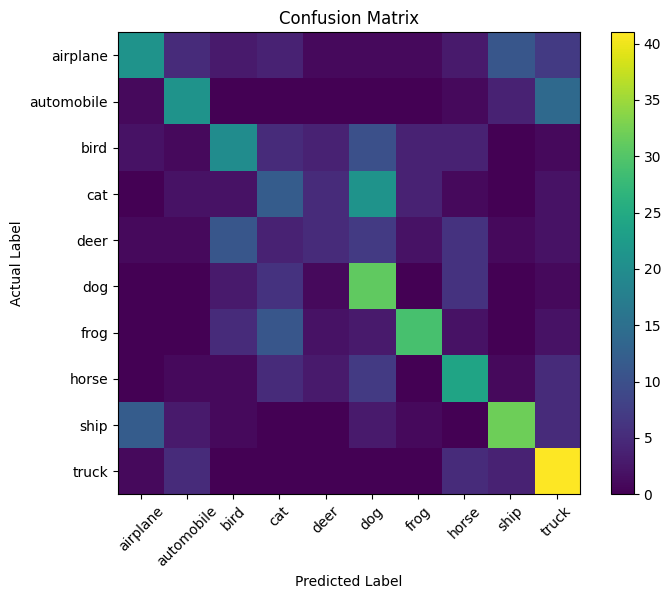

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.xticks(range(10), classes, rotation=45)
plt.yticks(range(10), classes)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.colorbar()

plt.show()

In [32]:
from sklearn.metrics import classification_report

print(classification_report(
    all_labels,
    all_predictions,
    target_names=classes,
    zero_division=0
))

              precision    recall  f1-score   support

    airplane       0.55      0.37      0.44        57
  automobile       0.54      0.51      0.53        41
        bird       0.43      0.39      0.41        51
         cat       0.26      0.24      0.25        49
        deer       0.24      0.12      0.16        40
         dog       0.37      0.65      0.47        48
        frog       0.71      0.54      0.61        54
       horse       0.46      0.51      0.48        47
        ship       0.60      0.56      0.58        57
       truck       0.51      0.73      0.60        56

    accuracy                           0.47       500
   macro avg       0.47      0.46      0.45       500
weighted avg       0.48      0.47      0.46       500



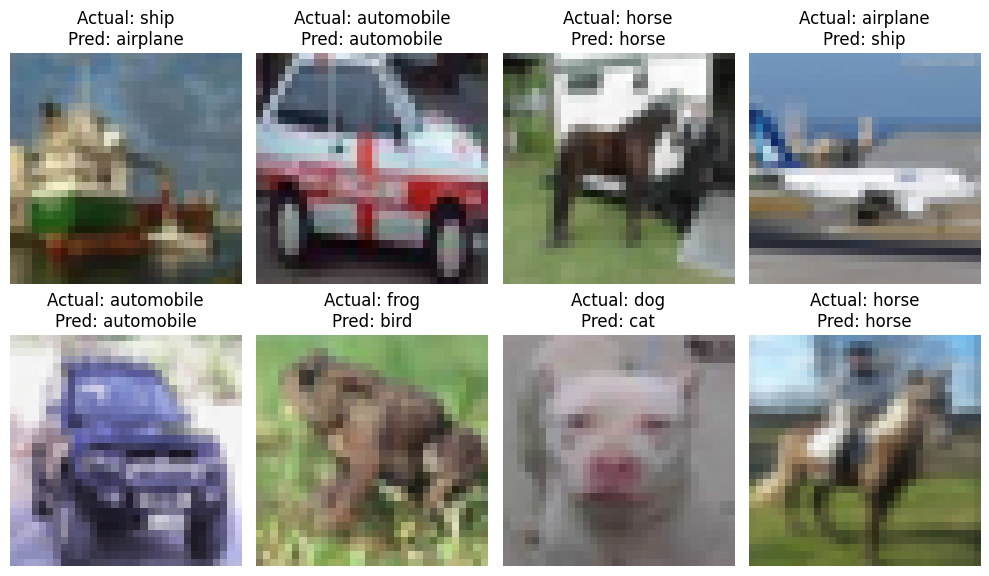

In [33]:
import matplotlib.pyplot as plt

model.eval()

images, labels = next(iter(test_loader))

with torch.no_grad():
    outputs, _ = model(images)
    predictions = torch.argmax(outputs, dim=1)

plt.figure(figsize=(10, 6))

for i in range(8):
    plt.subplot(2, 4, i + 1)

    image = images[i].permute(1, 2, 0)

    plt.imshow(image)
    plt.title(
        f"Actual: {classes[labels[i]]}\n"
        f"Pred: {classes[predictions[i]]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [35]:
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=2048, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
